In [1]:
import numpy as np
import networkx as nx


%load_ext autoreload
%autoreload 2

In [2]:
graphs_er = np.load("../Tutorials/ER/resolution-1/graphs-1_p-0.4.npy", allow_pickle=True)
graphs_er = [g[0] for g in graphs_er]
graphs_er_110_160 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_110-160.npy", allow_pickle=True)
g_er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)
graphs_er = graphs_er + graphs_er_110_160.tolist() + g_er_169.tolist()

graphs_pwl = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs_pwl = [g[0] for g in graphs_pwl]
graphs_pwl_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True)
g_pwl_169 = np.load("graphs/powerlaw_110-160/powerlaw_graph_169.npy", allow_pickle=True)
graphs_pwl = graphs_pwl + graphs_pwl_110_160.tolist() + g_pwl_169.tolist()

In [3]:
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4"
results_dir_pwl = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"

In [77]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
import numpy as np

graphs_results_er = {}

num_runs = 20
graphs_sizes = [int(g.number_of_nodes()) for g in graphs_er]  # 10-160 + 169

for g_size in graphs_sizes:
    hierarchical_metadatas = []
    path = results_dir_er + f"/graph_size={g_size}"

    for iter in range(num_runs):
        base_filename = f"{path}/er_p=0.4_iter_{iter}"
        hm = HierarchicalRunMetadata.load_from_files(base_filename)
        hierarchical_metadatas.append(hm)

    if g_size == 169:
        # runs-5-extra
        path_5 = f"{results_dir_er}/runs-5-extra/erdos-renyi_169/graph_size=169"
        for iter in range(5):
            base_filename = f"{path_5}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        # runs-20
        path_20 = f"{results_dir_er}/runs-20/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-20-extra
        path_20_extra = f"{results_dir_er}/runs-20-extra/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-55-extra
        path_55_extra = f"{results_dir_er}/runs-55-extra/erdos-renyi_169/graph_size=169"
        for iter in range(55):
            base_filename = f"{path_55_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        communities_list = []
        modularities_list = []
        times_list = []
        div_mods_list = []
        div_trees_list = []

        for p in [path_5, path_20, path_20_extra, path_55_extra]:
            communities_list.append(np.load(f"{p}/er_p=0.4_communities.npy", allow_pickle=True))
            modularities_list.append(np.load(f"{p}/er_p=0.4_modularities.npy", allow_pickle=True))
            times_list.append(np.load(f"{p}/er_p=0.4_times.npy", allow_pickle=True))
            div_mods_list.append(np.load(f"{p}/er_p=0.4_division_modularities.npy", allow_pickle=True))
            div_trees_list.append(np.load(f"{p}/er_p=0.4_division_trees.npy", allow_pickle=True))

        communities = np.concatenate(communities_list, axis=0)
        modularities = np.concatenate(modularities_list, axis=0)
        times = np.concatenate(times_list, axis=0)
        division_modularities = np.concatenate(div_mods_list, axis=0)
        division_trees = np.concatenate(div_trees_list, axis=0)

    else:
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)


    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = communities,
        modularities = modularities,
        times = times,
        division_modularities = division_modularities,
        division_trees = division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )


    graphs_results_er[g_size] = iterative_graph_results

In [52]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results_pwl = {}

num_runs = 20
graph_sizes = [int(g.number_of_nodes()) for g in graphs_er] # 10-160 + 169
base = f"./{results_dir_pwl}"


for g_size in graph_sizes:
    path = base + f"/graph_size={g_size}/"
    communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
    modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
    times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
    division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
    division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(3):
            base_filename = f"{path}-ex4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(21, 24, 1):
            base_filename = f"{path}-3runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = communities[:-4]
        modularities = modularities[:-4]
        times = times[:-4]
        division_modularities = division_modularities[:-4]
        division_trees = division_trees[:-4]

        communities = np.concatenate((communities, comms_3), axis=0)
        modularities = np.concatenate((modularities, mods_3), axis=0)
        times = np.concatenate((times, times_3), axis=0)
        division_modularities = np.concatenate((division_modularities, div_mods_3), axis=0)
        division_trees = np.concatenate((division_trees, div_trees_3), axis=0)

    elif g_size == 169:
        # -----------------------------
        # 169-extra-20runs
        # -----------------------------
        path_20 = path = base + f"/graph_size={g_size}-extra-20runs"
        for iter in range(20):
            base_filename = f"{path_20}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        # -----------------------------
        # 169-extra-30runs
        # -----------------------------
        path_30 = path = base + f"/graph_size={g_size}-extra-30runs"
        for iter in range(30):
            base_filename = f"{path_30}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = np.concatenate((comms_20, comms_30), axis=0)
        modularities = np.concatenate((mods_20, mods_30), axis=0)
        times = np.concatenate((times_20, times_30), axis=0)
        division_modularities = np.concatenate((div_mods_20, div_mods_30), axis=0)
        division_trees = np.concatenate((div_trees_20, div_trees_30), axis=0)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = communities,
        modularities = modularities,
        times = times,
        division_modularities = division_modularities,
        division_trees = division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_pwl[g_size] = iterative_graph_results

c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


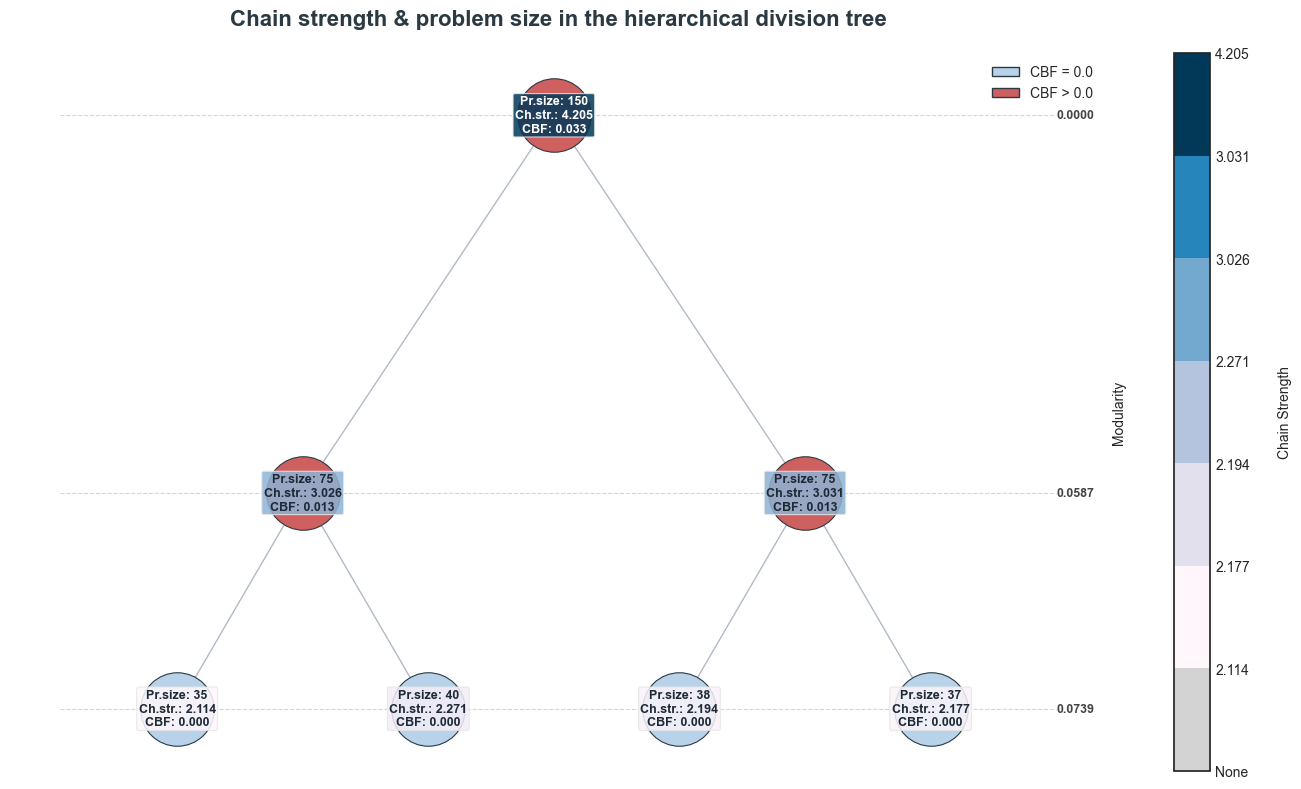

In [139]:
G = graphs_er[graphs_sizes.index(150)]
run_idx = 10
division_tree = graphs_results_er[150].division_trees[run_idx]
sampleset_metadatas = graphs_results_er[150].hierarchical_metadatas[run_idx]


from utils import recover_ordering, recover_info_ordering, plot_tree_extended


nodes, root = recover_ordering(G=G, division_tree=division_tree)
nodes_info, root_info = recover_info_ordering(root=root, nodes=nodes, sampleset_metadata=sampleset_metadatas)

from matplotlib import colormaps


cmap = colormaps.get_cmap("PuBu")
plot_tree_extended(root_info, division_modularities[run_idx], cmap=cmap)

c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


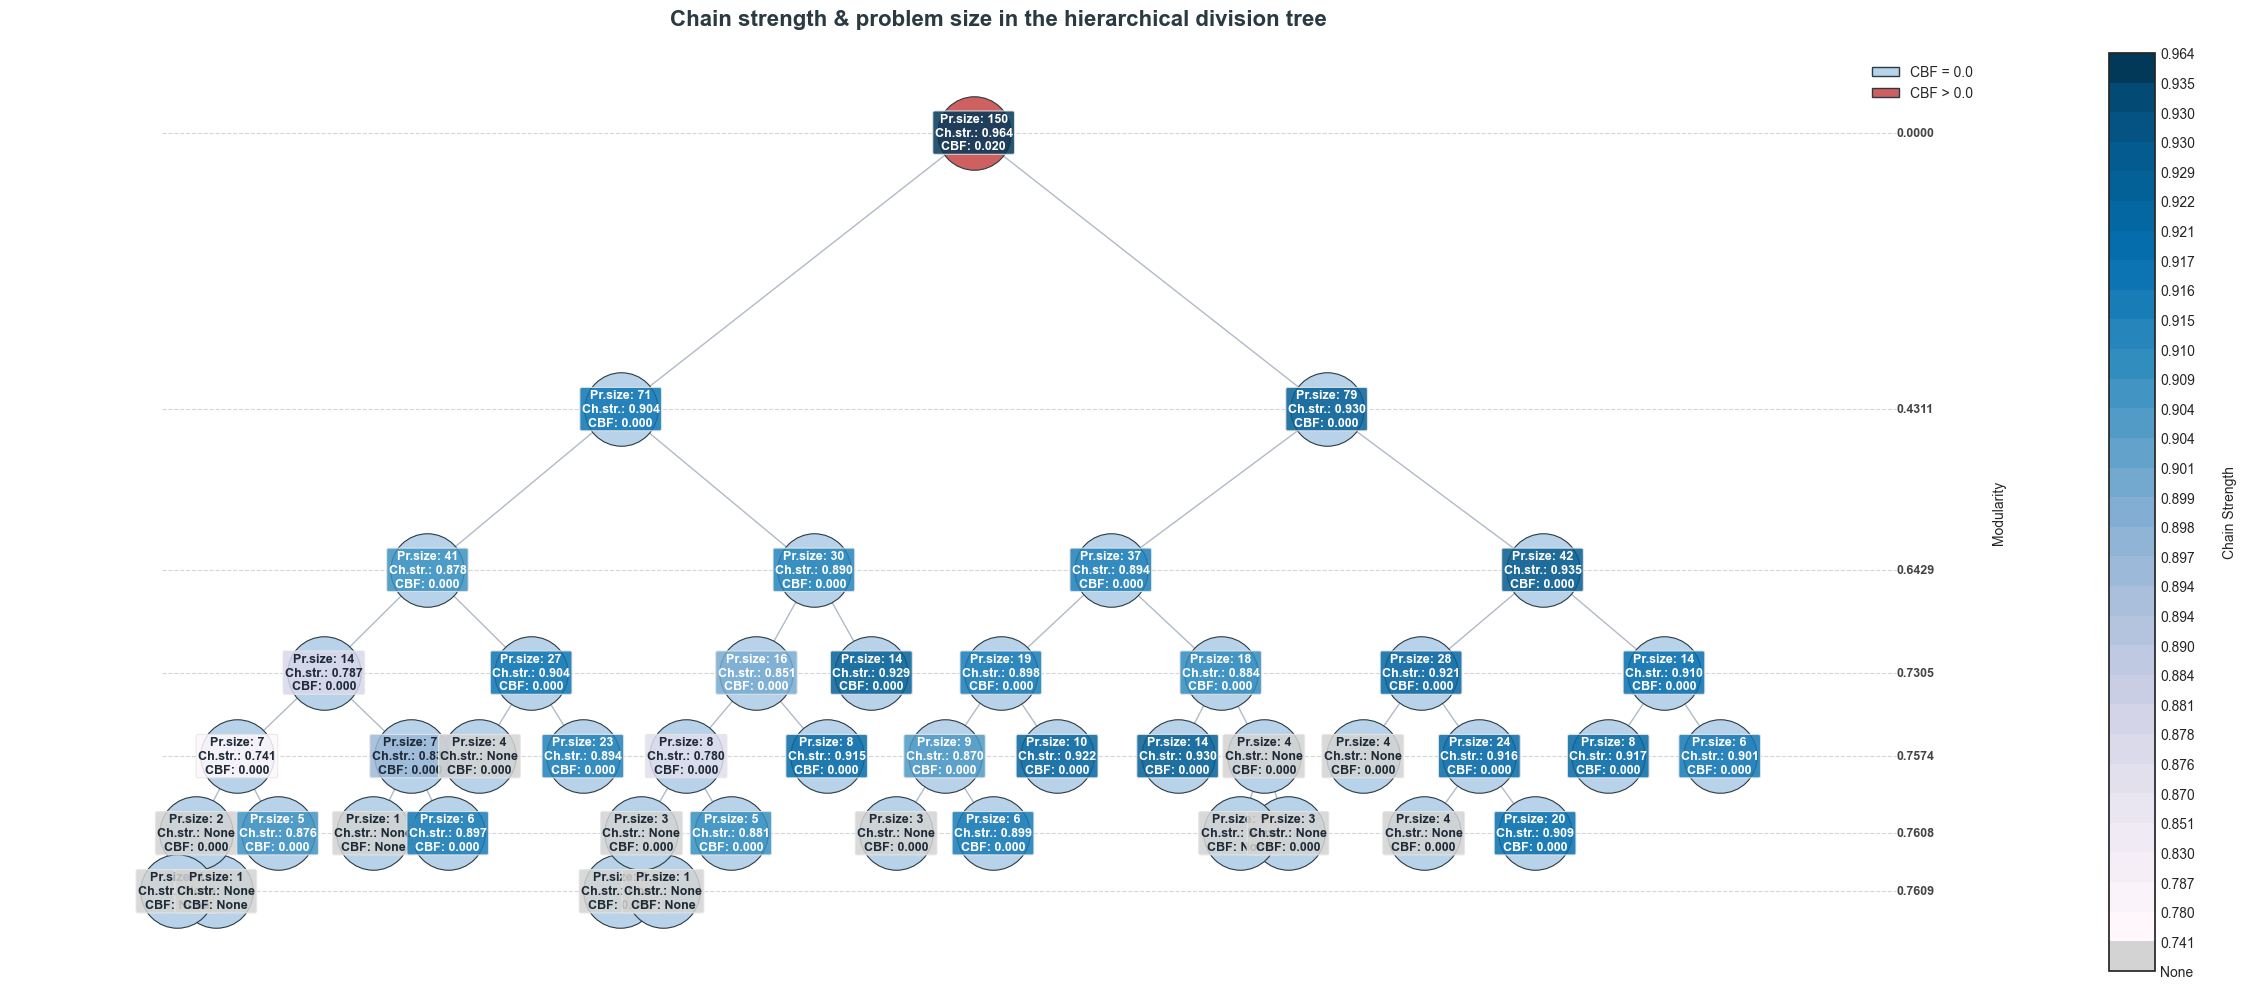

In [145]:
G = graphs_pwl[graphs_sizes.index(150)]
run_idx = 0
division_tree = graphs_results_pwl[150].division_trees[run_idx]
division_modularities = graphs_results_pwl[150].division_modularities
sampleset_metadatas = graphs_results_pwl[150].hierarchical_metadatas[run_idx]


from utils import recover_ordering, recover_info_ordering, plot_tree_extended


nodes, root = recover_ordering(G=G, division_tree=division_tree)
nodes_info, root_info = recover_info_ordering(root=root, nodes=nodes, sampleset_metadata=sampleset_metadatas)

from matplotlib import colormaps


cmap = colormaps.get_cmap("PuBu")
plot_tree_extended(root_info, division_modularities[run_idx], cmap=cmap, figsize=(25,10))